# Version A EDA

This notebook explores the finalized Food.com data pipeline in `Final/Data/Pure_Data`.

The EDA is organized around the revised project proposal:
- understand the full cleaned recipe and interaction space
- quantify sparsity and support for collaborative filtering
- show why hybrid recommendation is more appropriate than a single-model approach
- surface cold-start and low-history patterns that matter for evaluation and demo design
- save report-ready figures under `Final/Version_A/EDA/Figures`


In [1]:
from __future__ import annotations

import json
import os
from collections import Counter
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/nutrimatch_mpl")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

plt.switch_backend("Agg")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)


In [2]:
cwd = Path.cwd().resolve()
workspace_root = next((path for path in [cwd, *cwd.parents] if (path / "Final").exists()), None)
if workspace_root is None:
    raise FileNotFoundError("Could not locate workspace root with Final directory")

pure_data_dir = workspace_root / "Final" / "Data" / "Pure_Data"
figure_dir = workspace_root / "Final" / "Version_A" / "EDA" / "Figures"
figure_dir.mkdir(parents=True, exist_ok=True)

recipes = pd.read_csv(pure_data_dir / "recipes_clean.csv")
interactions_clean = pd.read_csv(pure_data_dir / "interactions_clean.csv")
interactions_filtered = pd.read_csv(pure_data_dir / "interactions_filtered.csv")
interactions_train_filtered = pd.read_csv(pure_data_dir / "interactions_train_filtered.csv")
interactions_test_filtered = pd.read_csv(pure_data_dir / "interactions_test_filtered.csv")
recipe_model = pd.read_csv(pure_data_dir / "recipe_model_table.csv")
user_stats = pd.read_csv(pure_data_dir / "user_statistics.csv")
preprocessing_summary = json.loads((pure_data_dir / "preprocessing_summary.json").read_text())
temporal_split_summary = json.loads((pure_data_dir / "temporal_split_summary.json").read_text())

recipes["tags_list"] = recipes["tags_list"].map(json.loads)
recipes["ingredients_list"] = recipes["ingredients_list"].map(json.loads)
recipes["submitted"] = pd.to_datetime(recipes["submitted"], errors="coerce")
interactions_clean["date"] = pd.to_datetime(interactions_clean["date"], errors="coerce")
interactions_filtered["date"] = pd.to_datetime(interactions_filtered["date"], errors="coerce")
interactions_train_filtered["date"] = pd.to_datetime(interactions_train_filtered["date"], errors="coerce")
interactions_test_filtered["date"] = pd.to_datetime(interactions_test_filtered["date"], errors="coerce")

recipes.shape, interactions_clean.shape, interactions_filtered.shape, interactions_train_filtered.shape, interactions_test_filtered.shape


((230543, 27), (1067281, 5), (533018, 5), (507043, 5), (10069, 5))

## Dataset Overview

The project now uses three related but different views of the data:
- the full cleaned interaction table for understanding the problem space
- the support-filtered interaction table for collaborative-filtering analysis
- the temporal train/test split for realistic offline evaluation


In [3]:
clean_user_count = preprocessing_summary["clean_user_count"]
clean_recipe_count = preprocessing_summary["clean_interacted_recipe_count"]
clean_interaction_count = preprocessing_summary["clean_interaction_rows"]
clean_sparsity = 1 - (clean_interaction_count / (clean_user_count * clean_recipe_count))

cf_user_count = temporal_split_summary["train_filtered_user_count"]
cf_recipe_count = temporal_split_summary["train_filtered_recipe_count"]
cf_interaction_count = temporal_split_summary["train_filtered_interaction_rows"]
cf_sparsity = 1 - (cf_interaction_count / (cf_user_count * cf_recipe_count))

overview = pd.DataFrame(
    {
        "metric": [
            "total cleaned recipes",
            "clean users",
            "recipes with clean interactions",
            "clean interactions",
            "dropped interactions missing cleaned recipe ids",
            "global filtered interactions",
            "CF-eligible users (global filtered view)",
            "CF-eligible recipes (global filtered view)",
            "temporal holdout users",
            "train filtered interactions",
            "test filtered interactions",
            "clean matrix sparsity",
            "CF train matrix sparsity",
            "share of quick recipes (<= 30 min)",
        ],
        "value": [
            len(recipes),
            clean_user_count,
            clean_recipe_count,
            clean_interaction_count,
            preprocessing_summary["dropped_interactions_missing_clean_recipe"],
            preprocessing_summary["filtered_interaction_rows"],
            preprocessing_summary["filtered_user_count"],
            preprocessing_summary["filtered_recipe_count"],
            temporal_split_summary["eligible_eval_user_count"],
            cf_interaction_count,
            temporal_split_summary["test_filtered_interaction_rows"],
            round(clean_sparsity, 6),
            round(cf_sparsity, 6),
            round(float(recipes["quick_recipe"].mean()), 4),
        ],
    }
)

overview


,metric,value
0,total cleaned recipes,2.305430e+05
1,clean users,1.954680e+05
2,recipes with clean interactions,2.255300e+05
3,clean interactions,1.067281e+06
4,dropped interactions missing cleaned recipe ids,4.239000e+03
5,global filtered interactions,5.330180e+05
6,CF-eligible users (global filtered view),1.697300e+04
7,CF-eligible recipes (global filtered view),3.984400e+04
8,temporal holdout users,5.554700e+04
9,train filtered interactions,5.070430e+05


In [4]:
data_quality = pd.DataFrame(
    {
        "column": [
            "description",
            "submitted",
            "calories",
            "protein_pdv",
            "combined_text",
        ],
        "missing_or_blank_rate": [
            round(float((recipes["description"].fillna("").str.strip() == "").mean()), 4),
            round(float(recipes["submitted"].isna().mean()), 4),
            round(float(recipes["calories"].isna().mean()), 4),
            round(float(recipes["protein_pdv"].isna().mean()), 4),
            round(float((recipe_model["combined_text"].fillna("").str.strip() == "").mean()), 4),
        ],
    }
)

data_quality


,column,missing_or_blank_rate
0,description,0.0187
1,submitted,0.0000
2,calories,0.0000
3,protein_pdv,0.0000
4,combined_text,0.0000


## Recipe Metadata Distributions

These figures help justify the practical filters proposed in the project, especially preparation time and nutrition-aware ranking.

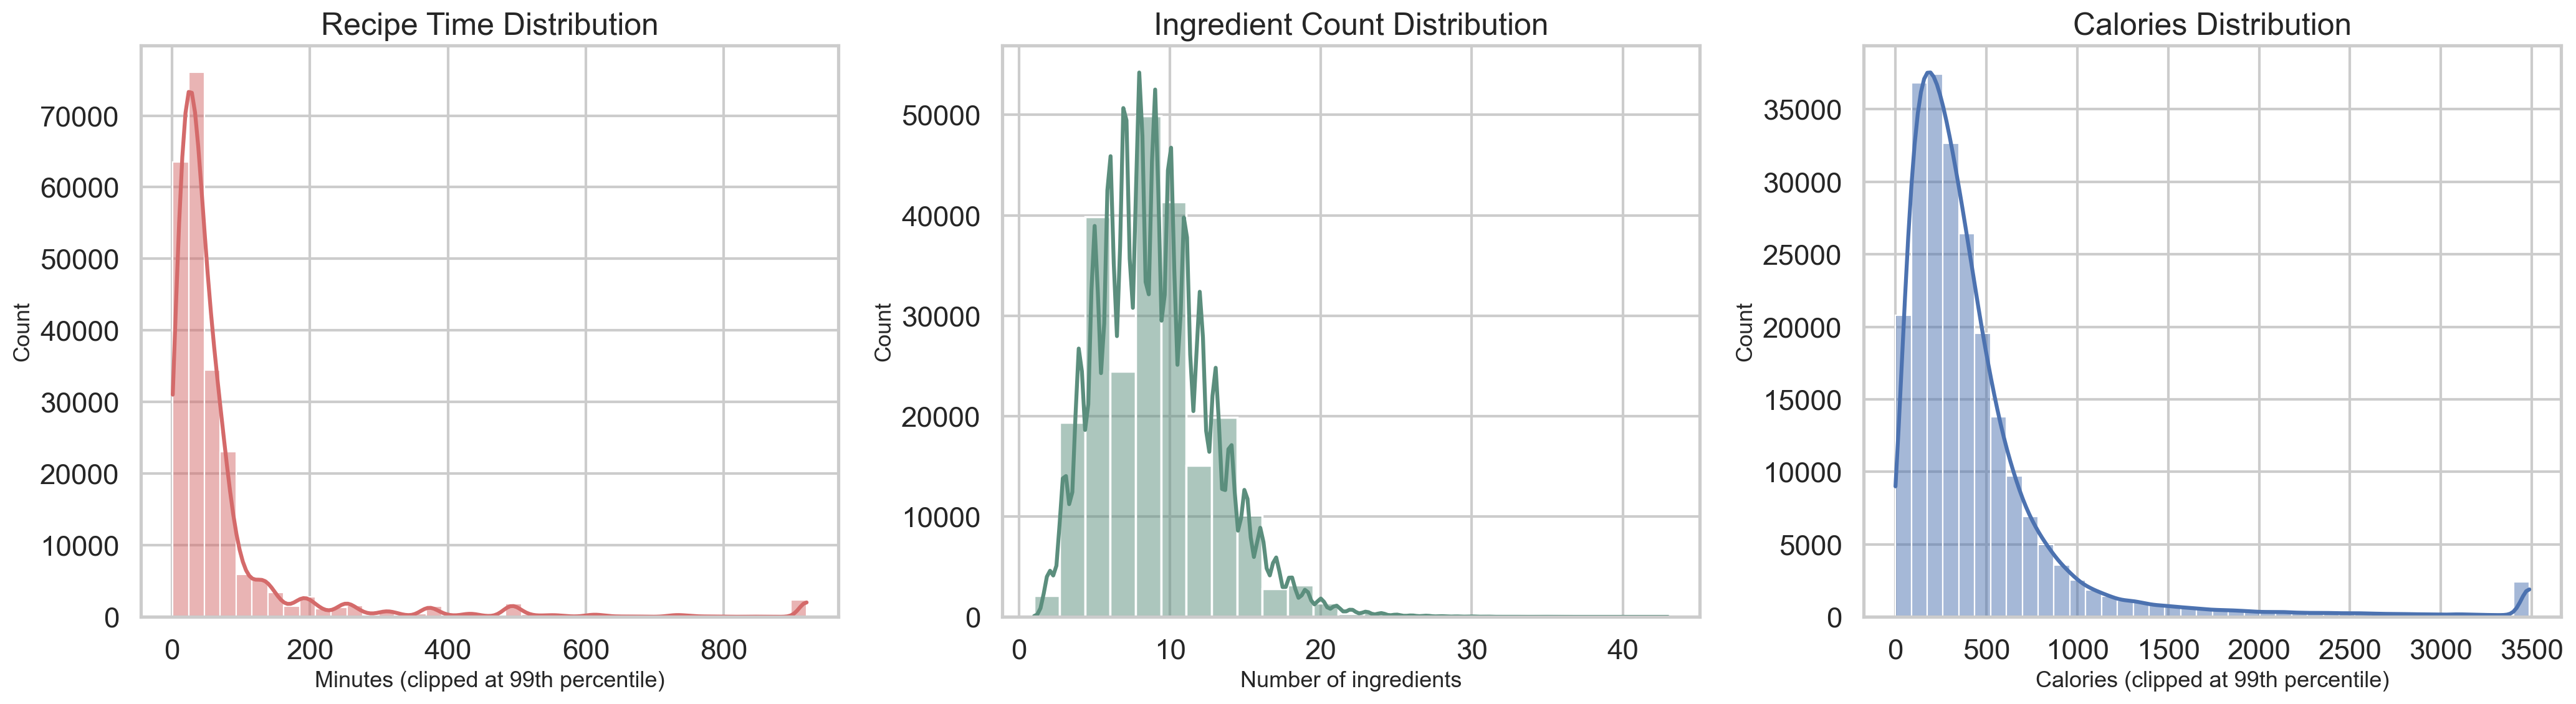

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

minutes_clip = recipes["minutes"].clip(upper=recipes["minutes"].quantile(0.99))
calories_clip = recipes["calories"].clip(upper=recipes["calories"].quantile(0.99))

sns.histplot(minutes_clip, bins=40, kde=True, ax=axes[0], color="#d46a6a")
axes[0].set_title("Recipe Time Distribution")
axes[0].set_xlabel("Minutes (clipped at 99th percentile)")

sns.histplot(recipes["n_ingredients"], bins=25, kde=True, ax=axes[1], color="#5b8e7d")
axes[1].set_title("Ingredient Count Distribution")
axes[1].set_xlabel("Number of ingredients")

sns.histplot(calories_clip, bins=40, kde=True, ax=axes[2], color="#4c72b0")
axes[2].set_title("Calories Distribution")
axes[2].set_xlabel("Calories (clipped at 99th percentile)")

fig.tight_layout()
figure_path = figure_dir / "recipe_metadata_distributions.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
display(Image(filename=str(figure_path)))
plt.close(fig)


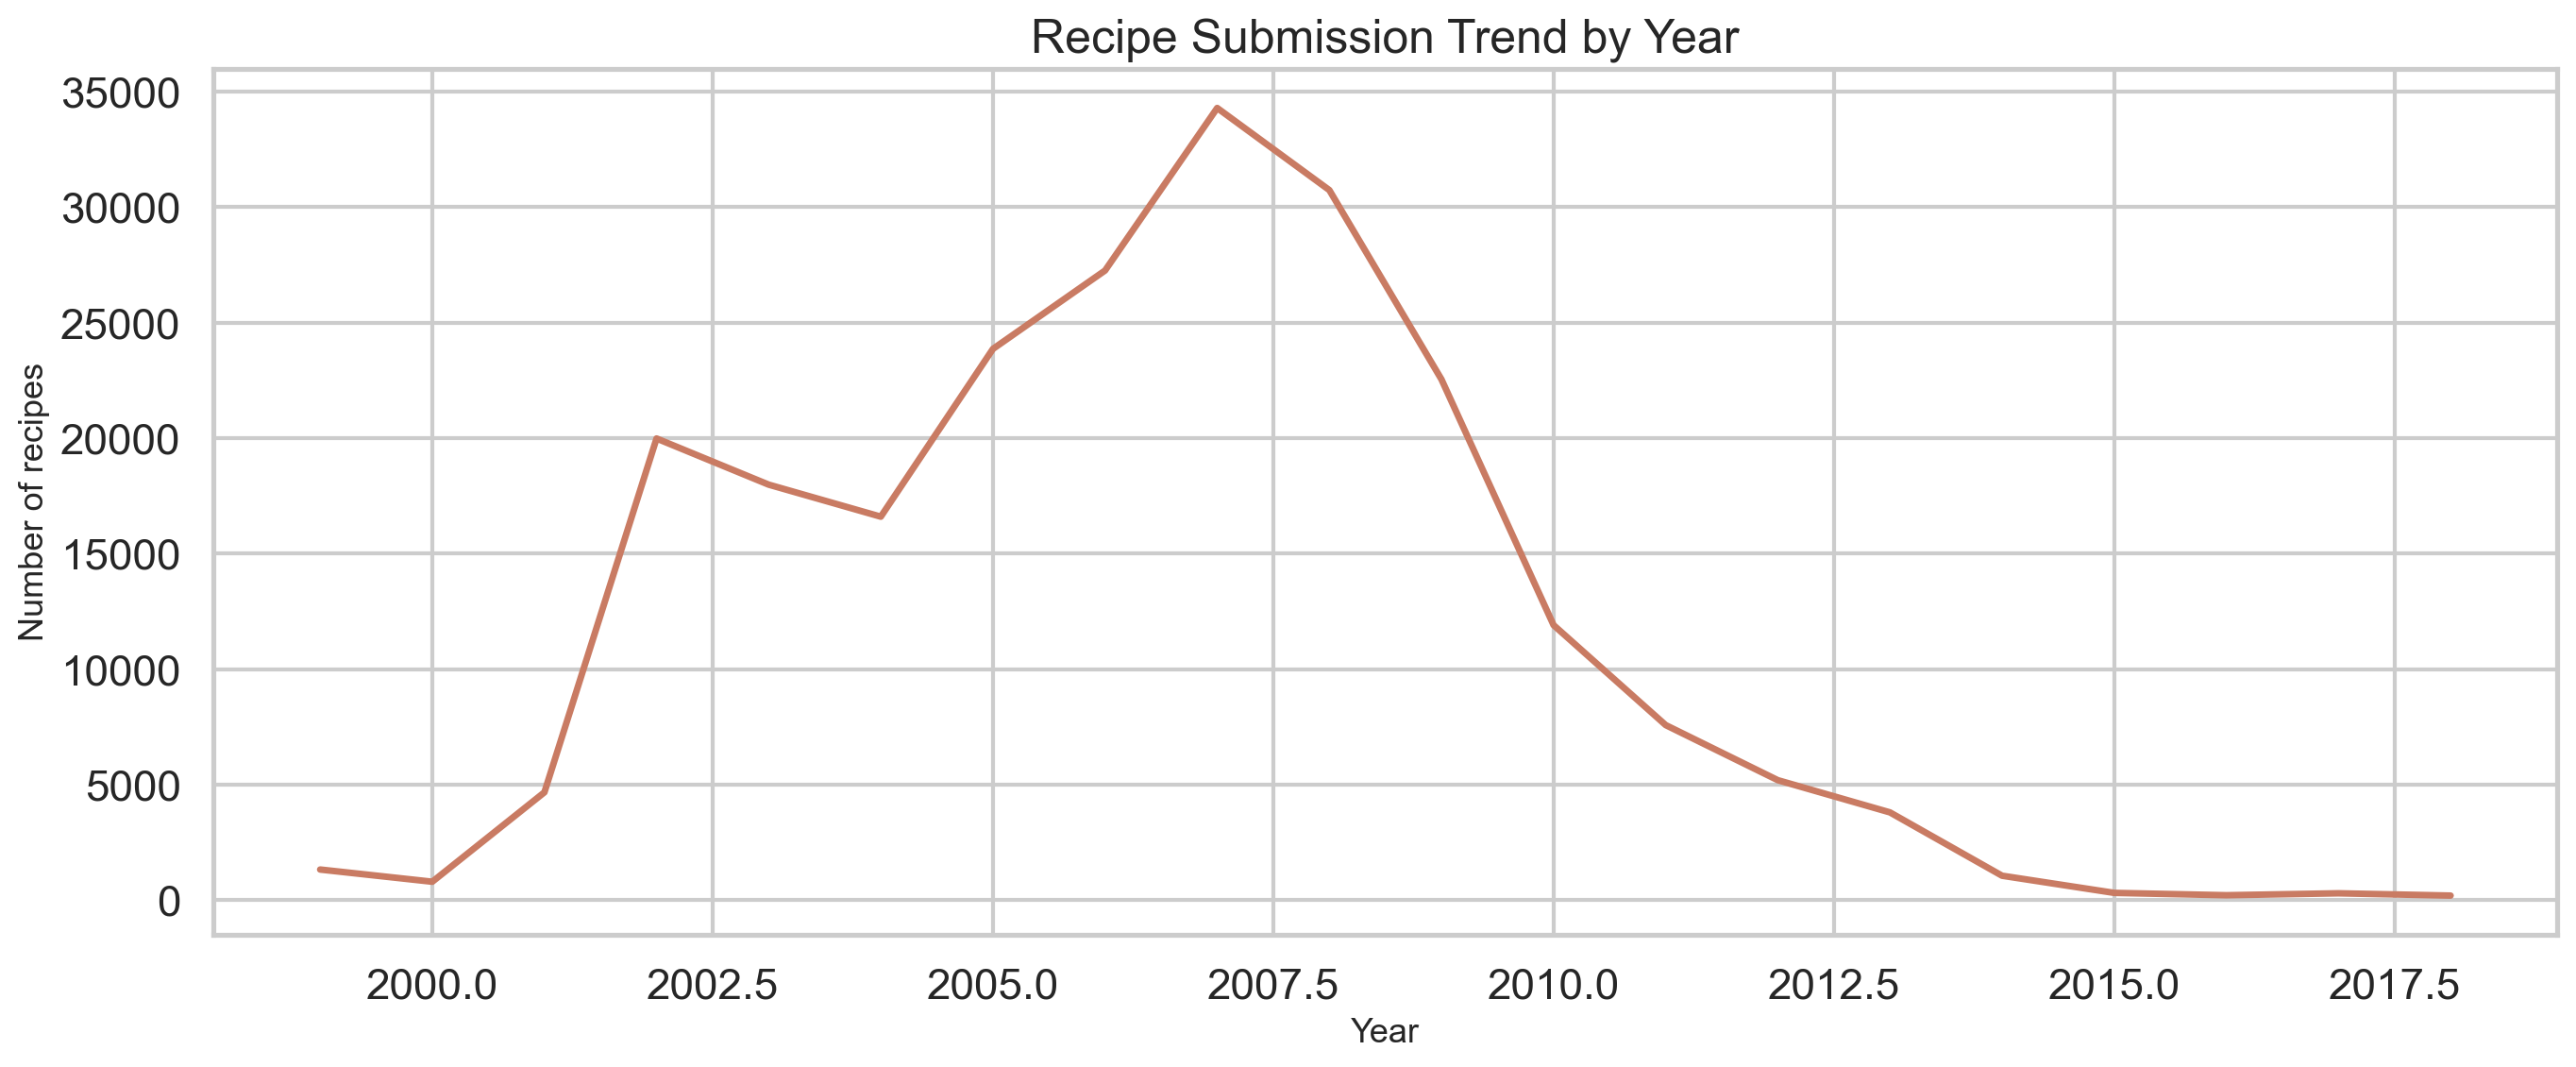

,submitted_year,recipe_count
15,2014,1049
16,2015,306
17,2016,204
18,2017,288
19,2018,189


In [6]:
submission_trend = recipes.groupby("submitted_year").size().reset_index(name="recipe_count")
submission_trend = submission_trend.dropna().sort_values("submitted_year")

plt.figure(figsize=(14, 6))
sns.lineplot(data=submission_trend, x="submitted_year", y="recipe_count", linewidth=2.5, color="#c97b63")
plt.title("Recipe Submission Trend by Year")
plt.xlabel("Year")
plt.ylabel("Number of recipes")
plt.tight_layout()
figure_path = figure_dir / "recipe_submission_trend.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
display(Image(filename=str(figure_path)))
plt.close()

submission_trend.tail()


## Interaction and Evaluation Patterns

The project evaluates Top-N recommendation under a temporal holdout setup, so the EDA should reflect both the full interaction space and the filtered evaluation subset.

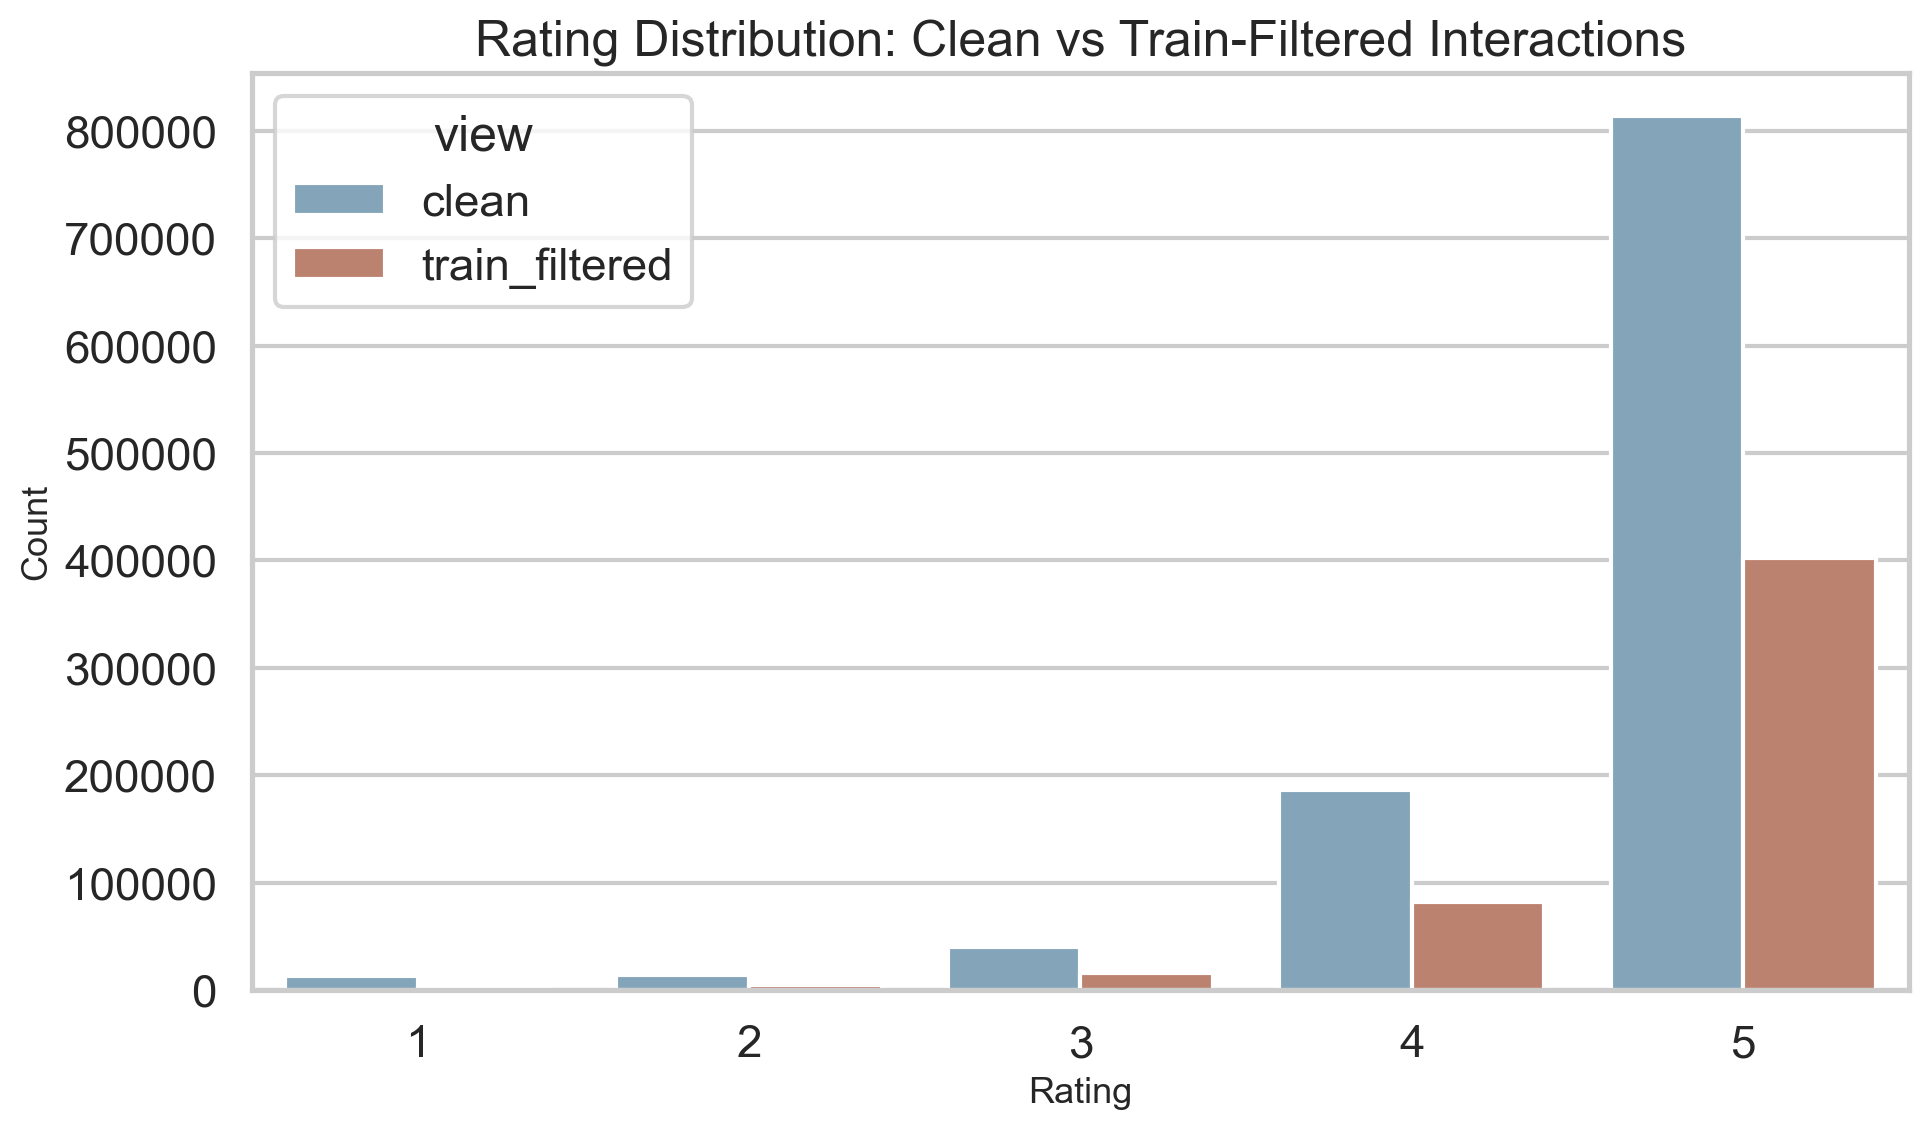

,view,rating,count
0,clean,1,12734
1,clean,2,14048
2,clean,3,40638
3,clean,4,186441
4,clean,5,813420
5,train_filtered,1,2043
6,train_filtered,2,4559
7,train_filtered,3,16368
8,train_filtered,4,82208
9,train_filtered,5,401865


In [7]:
rating_dist = pd.concat(
    [
        interactions_clean.assign(view="clean"),
        interactions_train_filtered.assign(view="train_filtered"),
    ],
    ignore_index=True,
)
rating_dist = (
    rating_dist.groupby(["view", "rating"]).size().reset_index(name="count")
)

plt.figure(figsize=(10, 6))
sns.barplot(data=rating_dist, x="rating", y="count", hue="view", palette=["#7aa6c2", "#c97b63"])
plt.title("Rating Distribution: Clean vs Train-Filtered Interactions")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
figure_path = figure_dir / "rating_distribution.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
display(Image(filename=str(figure_path)))
plt.close()

rating_dist


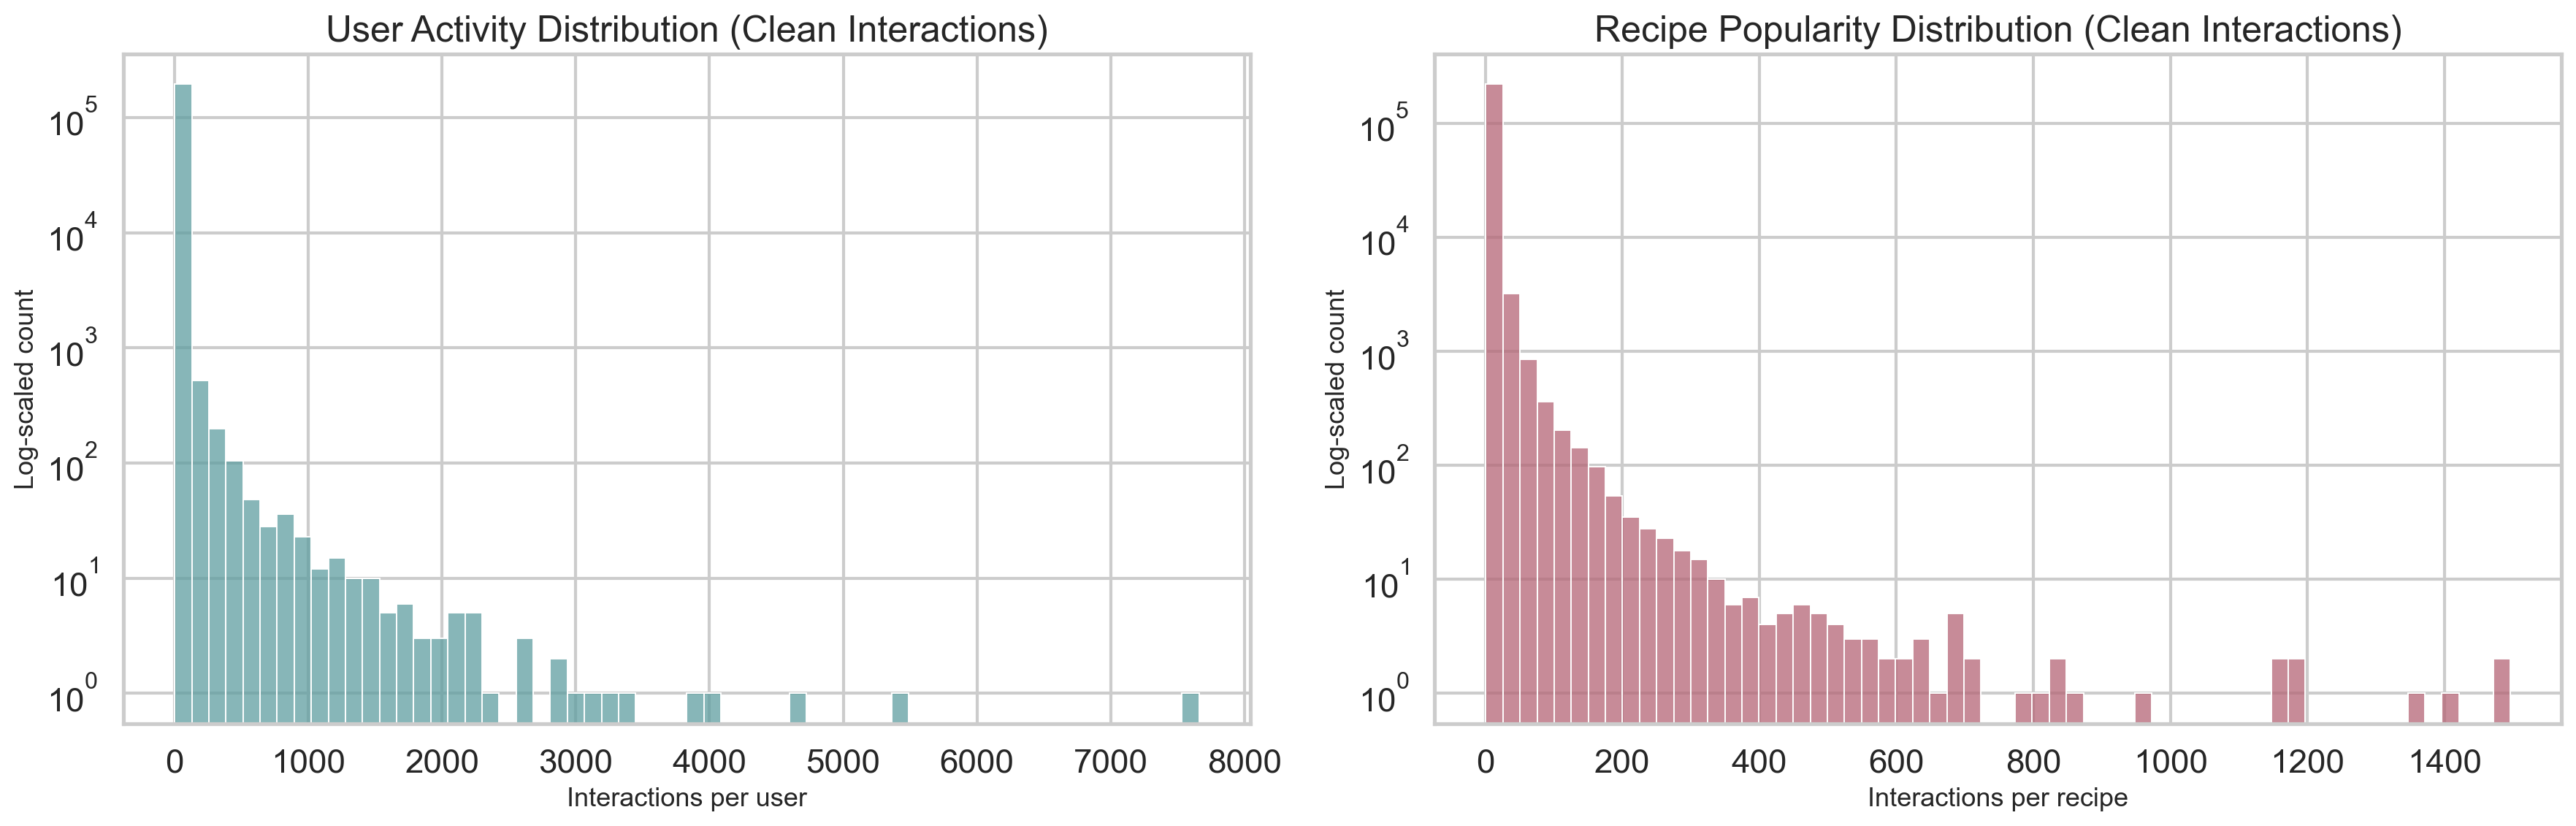

,quantile,user_interactions,recipe_interactions
0,0.25,1.0,1.0
1,0.50,1.0,2.0
2,0.75,2.0,4.0
3,0.90,5.0,9.0
4,0.95,12.0,14.0
5,0.99,68.0,45.0


In [8]:
clean_user_activity = interactions_clean["user_id"].value_counts().rename("interaction_count").reset_index(drop=True)
clean_recipe_popularity = interactions_clean["recipe_id"].value_counts().rename("interaction_count").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(clean_user_activity, bins=60, ax=axes[0], color="#5f9ea0")
axes[0].set_yscale("log")
axes[0].set_title("User Activity Distribution (Clean Interactions)")
axes[0].set_xlabel("Interactions per user")
axes[0].set_ylabel("Log-scaled count")

sns.histplot(clean_recipe_popularity, bins=60, ax=axes[1], color="#b56576")
axes[1].set_yscale("log")
axes[1].set_title("Recipe Popularity Distribution (Clean Interactions)")
axes[1].set_xlabel("Interactions per recipe")
axes[1].set_ylabel("Log-scaled count")

fig.tight_layout()
figure_path = figure_dir / "interaction_density_distributions.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
display(Image(filename=str(figure_path)))
plt.close(fig)

interaction_quantiles = pd.DataFrame(
    {
        "quantile": [0.25, 0.5, 0.75, 0.9, 0.95, 0.99],
        "user_interactions": clean_user_activity.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).values,
        "recipe_interactions": clean_recipe_popularity.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).values,
    }
)

interaction_quantiles


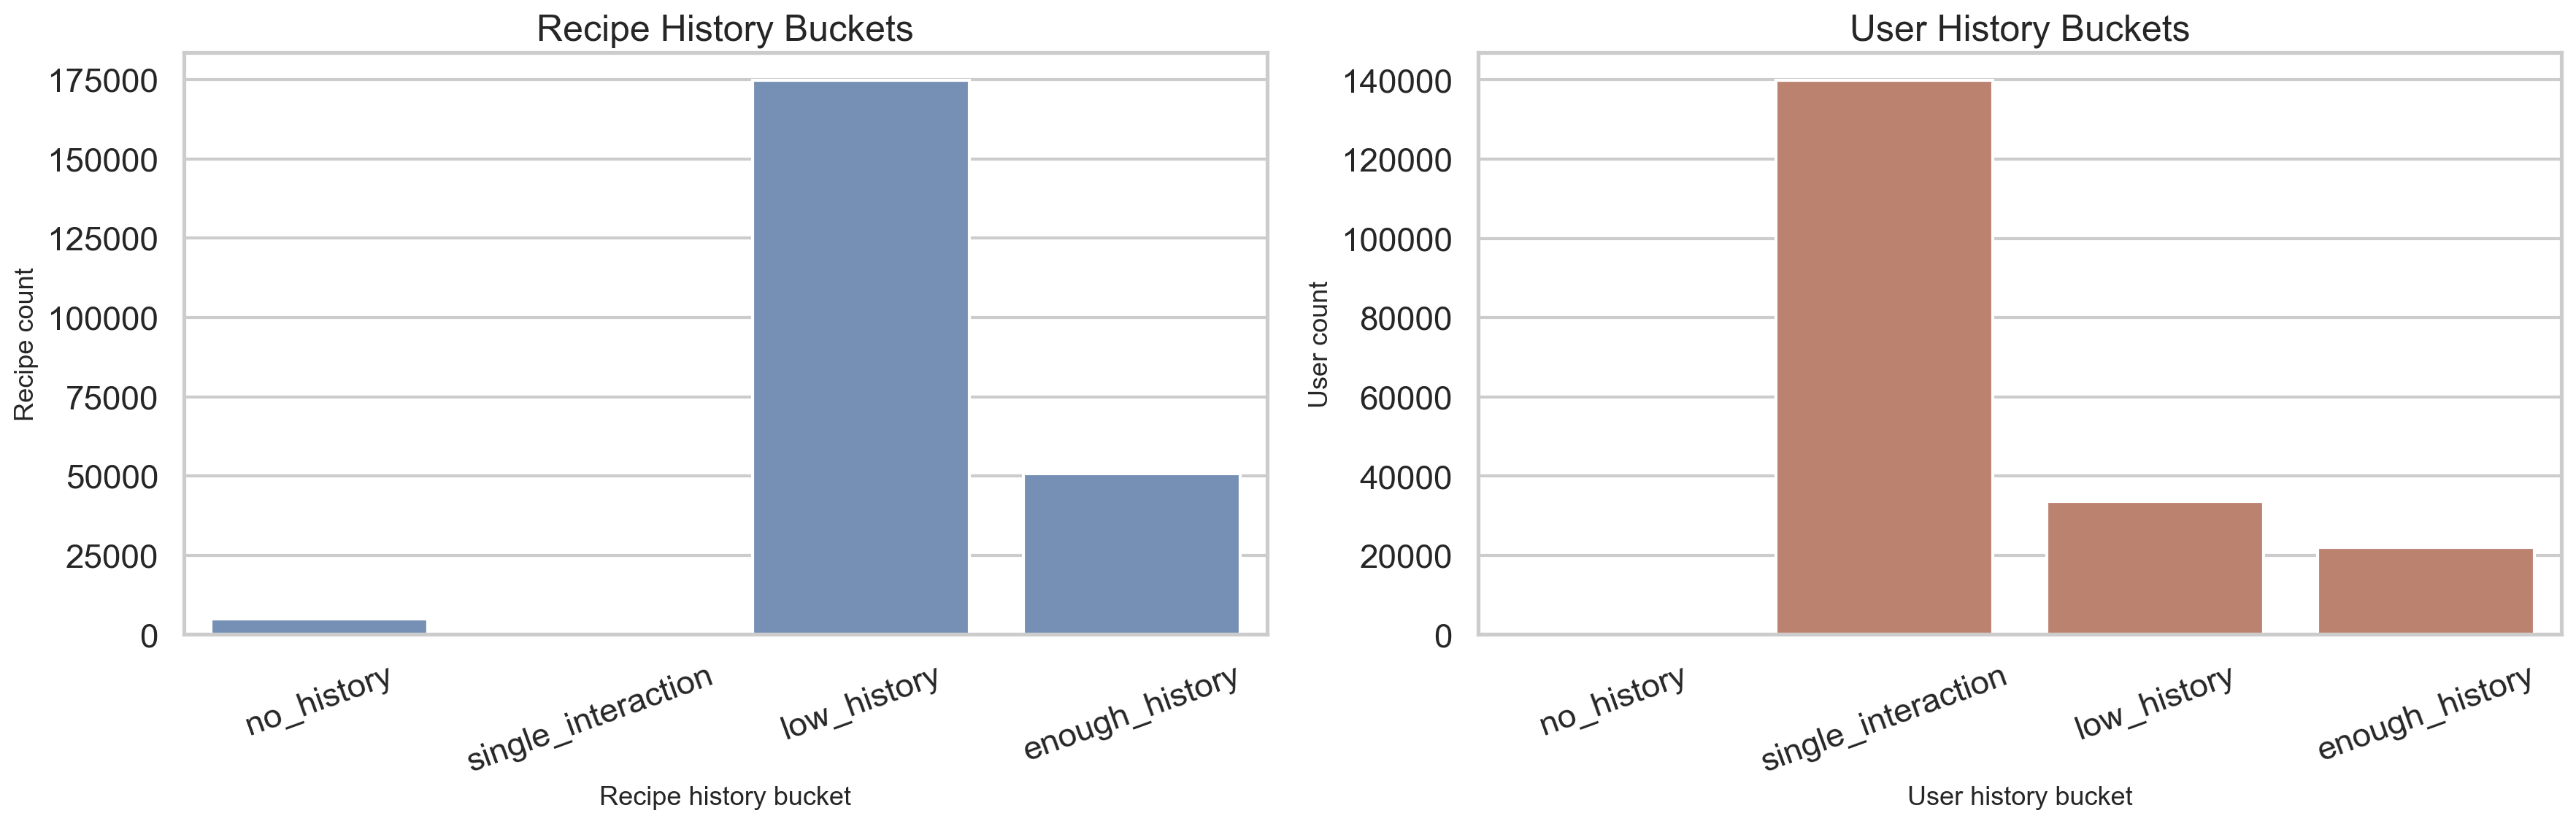

(           bucket   count
 2      no_history    5013
 0     low_history  174775
 1  enough_history   50755,
                bucket   count
 0  single_interaction  139921
 1         low_history   33614
 2      enough_history   21933)

In [9]:
recipe_history = recipe_model["history_bucket"].value_counts().rename_axis("bucket").reset_index(name="count")
user_history = user_stats["history_bucket"].value_counts().rename_axis("bucket").reset_index(name="count")

bucket_order = ["no_history", "single_interaction", "low_history", "enough_history"]
recipe_history["bucket"] = pd.Categorical(recipe_history["bucket"], categories=bucket_order, ordered=True)
user_history["bucket"] = pd.Categorical(user_history["bucket"], categories=bucket_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=recipe_history.sort_values("bucket"), x="bucket", y="count", ax=axes[0], color="#6c8ebf")
axes[0].set_title("Recipe History Buckets")
axes[0].set_xlabel("Recipe history bucket")
axes[0].set_ylabel("Recipe count")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=user_history.sort_values("bucket"), x="bucket", y="count", ax=axes[1], color="#c97b63")
axes[1].set_title("User History Buckets")
axes[1].set_xlabel("User history bucket")
axes[1].set_ylabel("User count")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
figure_path = figure_dir / "history_bucket_overview.png"
fig.savefig(figure_path, dpi=200, bbox_inches="tight")
display(Image(filename=str(figure_path)))
plt.close(fig)

recipe_history.sort_values("bucket"), user_history.sort_values("bucket")


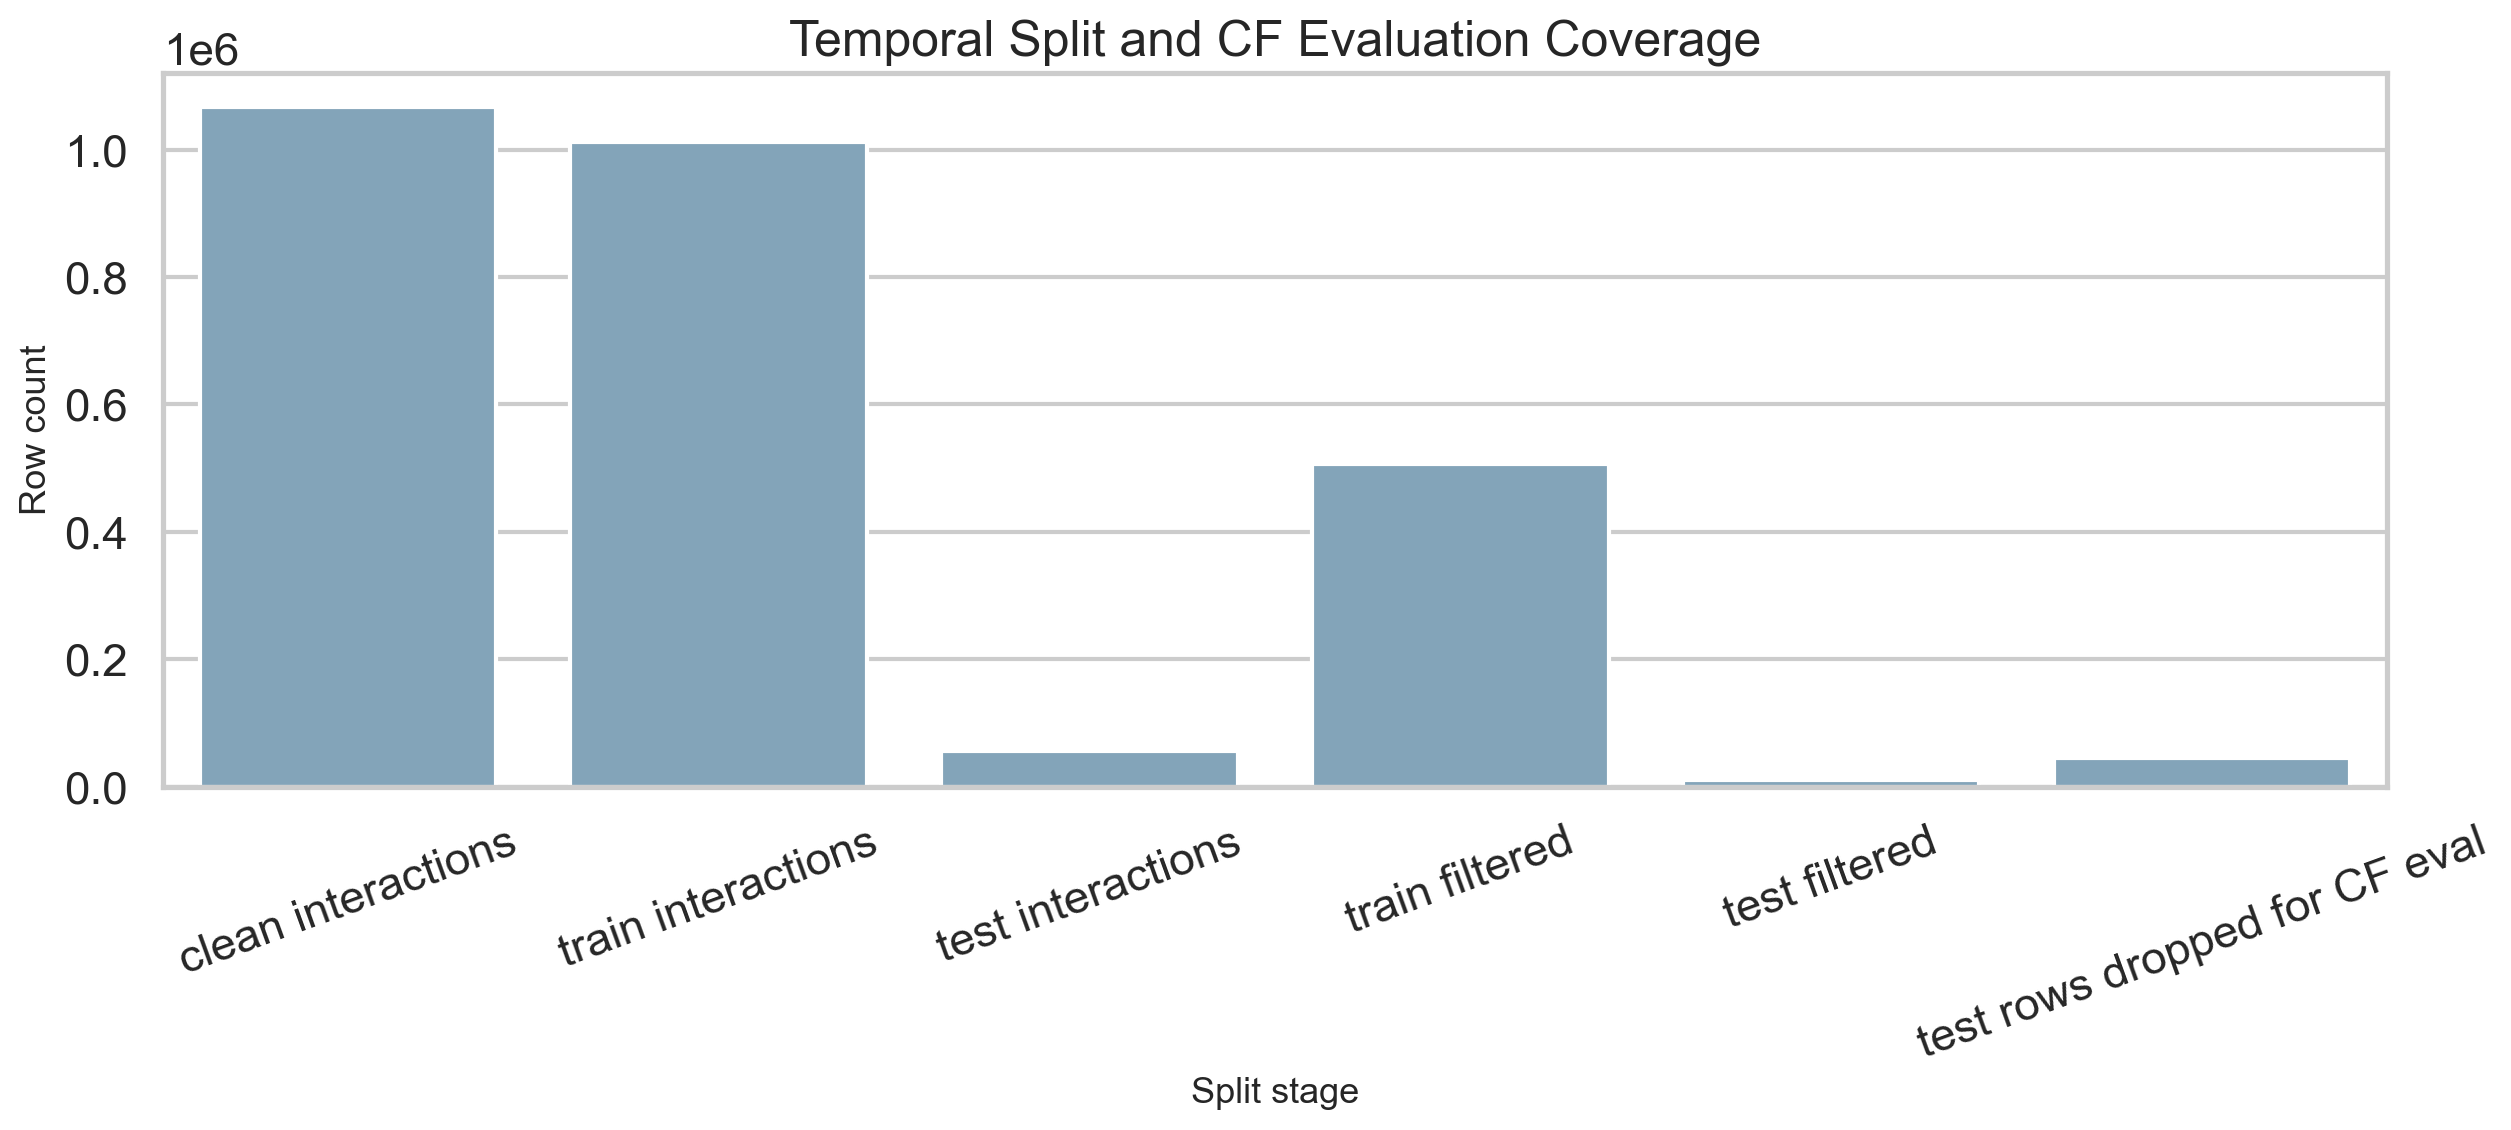

,stage,count
0,clean interactions,1067281
1,train interactions,1011734
2,test interactions,55547
3,train filtered,507043
4,test filtered,10069
5,test rows dropped for CF eval,45478


In [10]:
split_overview = pd.DataFrame(
    {
        "stage": [
            "clean interactions",
            "train interactions",
            "test interactions",
            "train filtered",
            "test filtered",
            "test rows dropped for CF eval",
        ],
        "count": [
            preprocessing_summary["clean_interaction_rows"],
            temporal_split_summary["train_interaction_rows"],
            temporal_split_summary["test_interaction_rows"],
            temporal_split_summary["train_filtered_interaction_rows"],
            temporal_split_summary["test_filtered_interaction_rows"],
            temporal_split_summary["test_rows_dropped_for_cf_evaluation"],
        ],
    }
)

plt.figure(figsize=(13, 6))
sns.barplot(data=split_overview, x="stage", y="count", color="#7aa6c2")
plt.title("Temporal Split and CF Evaluation Coverage")
plt.xlabel("Split stage")
plt.ylabel("Row count")
plt.xticks(rotation=20)
plt.tight_layout()
figure_path = figure_dir / "temporal_split_summary.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
display(Image(filename=str(figure_path)))
plt.close()

split_overview


## Content Signals

These plots support the content-based and hybrid parts of the proposal by showing that recipe metadata is rich and semantically meaningful.

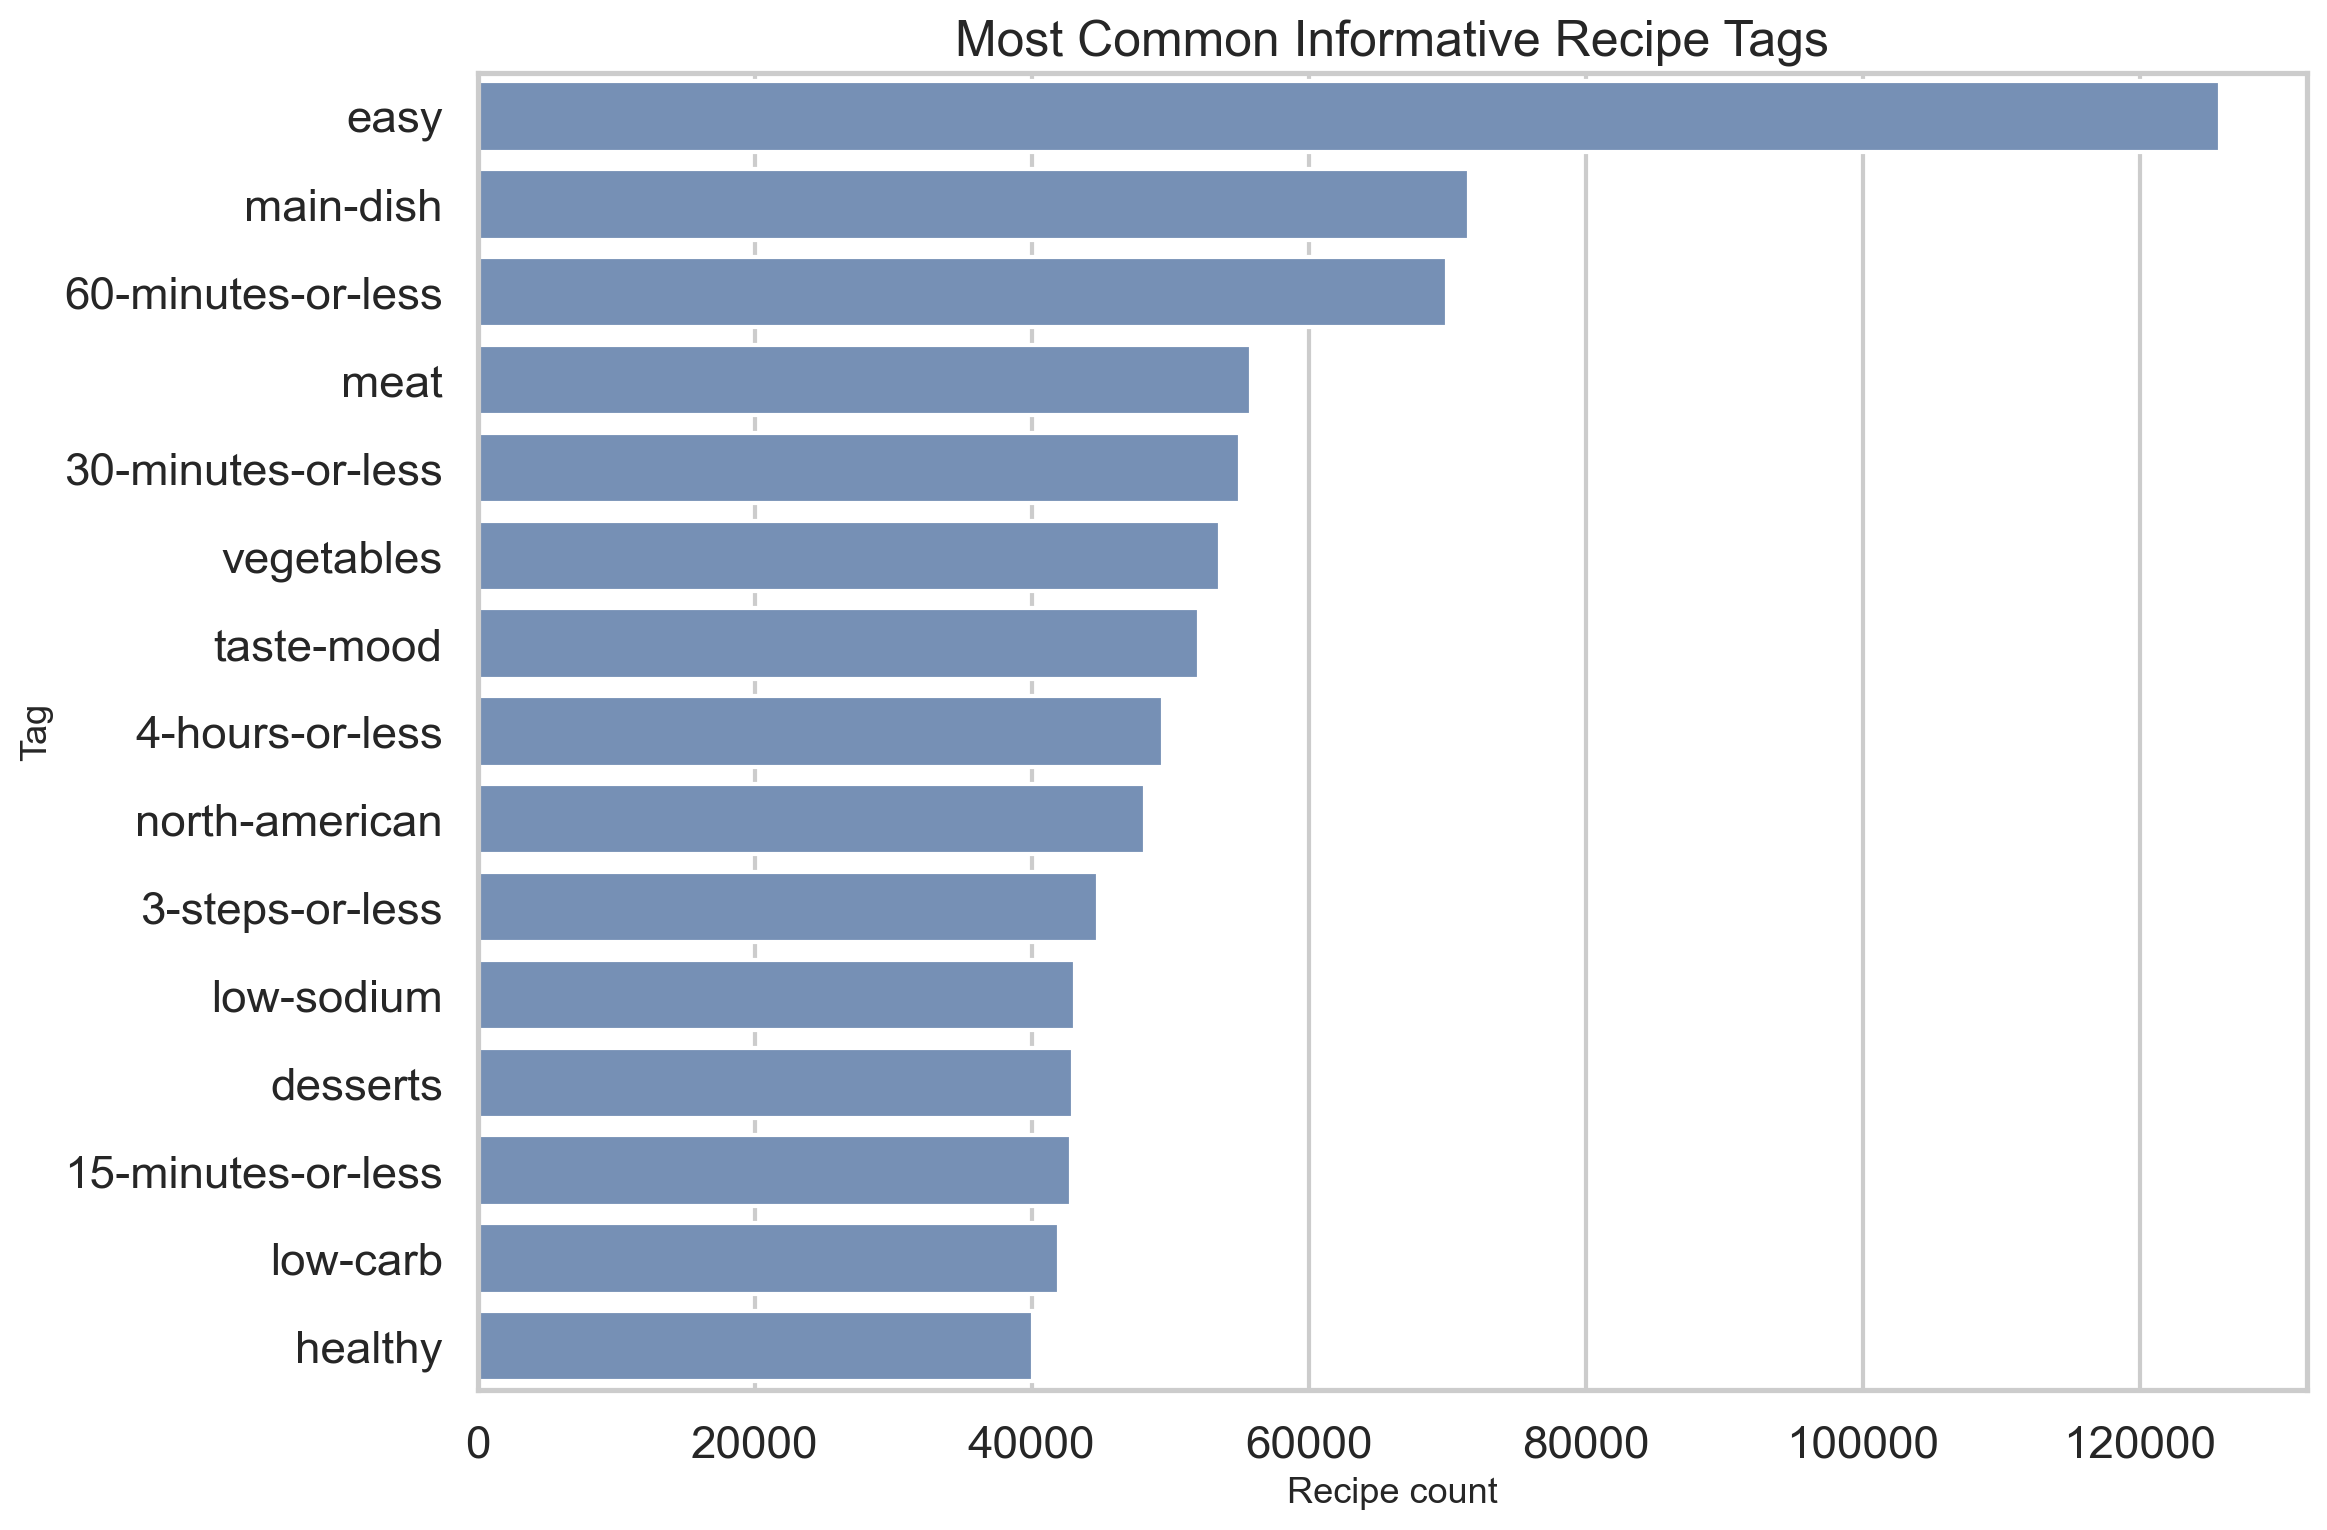

,tag,count
0,easy,125816
1,main-dish,71602
2,60-minutes-or-less,69990
3,meat,55818
4,30-minutes-or-less,55077
5,vegetables,53614
6,taste-mood,52093
7,4-hours-or-less,49497
8,north-american,48214
9,3-steps-or-less,44828


In [11]:
generic_tags = {
    "preparation",
    "time-to-make",
    "course",
    "main-ingredient",
    "dietary",
    "occasion",
    "cuisine",
    "low-in-something",
    "equipment",
    "number-of-servings",
}

tag_counter = Counter()
for tags in recipes["tags_list"]:
    tag_counter.update(tag for tag in tags if tag not in generic_tags)

top_tags = pd.DataFrame(tag_counter.most_common(15), columns=["tag", "count"])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_tags, y="tag", x="count", color="#6c8ebf")
plt.title("Most Common Informative Recipe Tags")
plt.xlabel("Recipe count")
plt.ylabel("Tag")
plt.tight_layout()
figure_path = figure_dir / "top_informative_tags.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
display(Image(filename=str(figure_path)))
plt.close()

top_tags


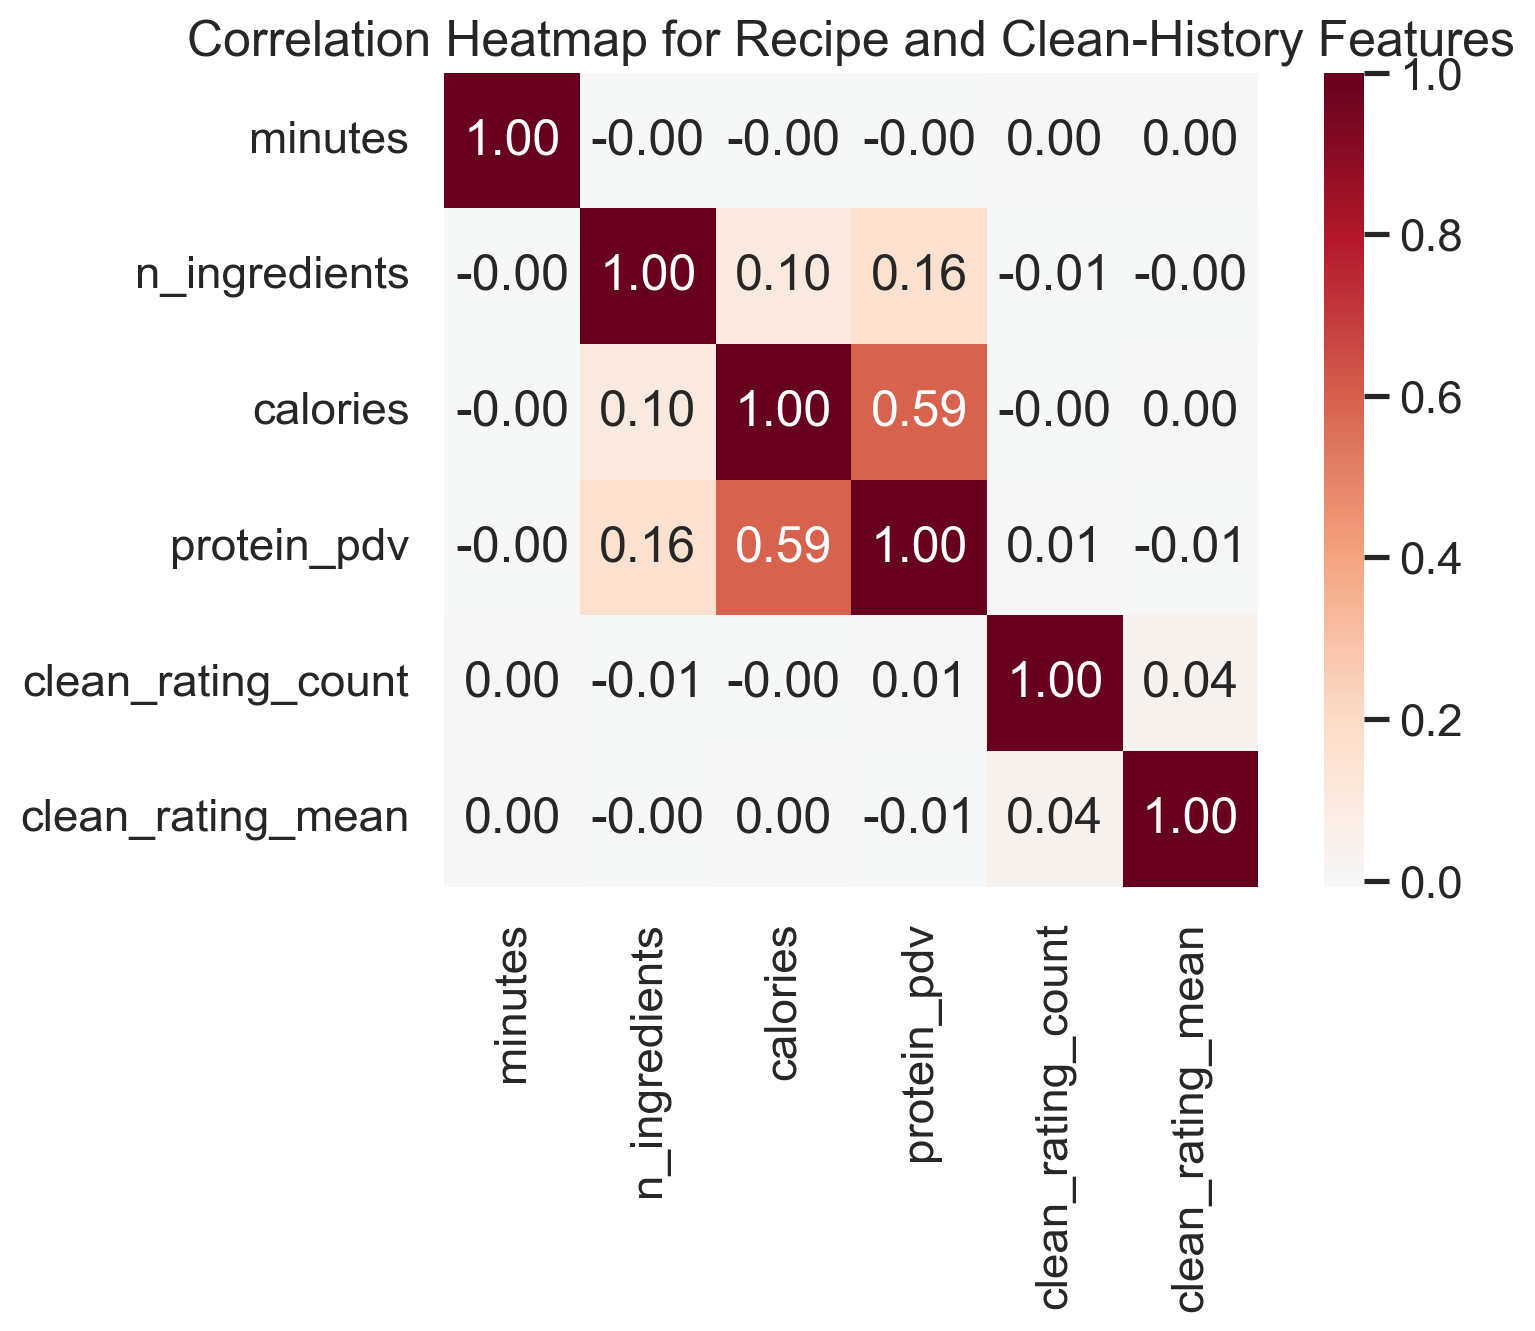

,minutes,n_ingredients,calories,protein_pdv,clean_rating_count,clean_rating_mean
minutes,1.000,-0.001,-0.000,-0.001,0.002,0.001
n_ingredients,-0.001,1.000,0.099,0.160,-0.008,-0.001
calories,-0.000,0.099,1.000,0.593,-0.005,0.001
protein_pdv,-0.001,0.160,0.593,1.000,0.005,-0.006
clean_rating_count,0.002,-0.008,-0.005,0.005,1.000,0.036
clean_rating_mean,0.001,-0.001,0.001,-0.006,0.036,1.000


In [12]:
corr_cols = [
    "minutes",
    "n_ingredients",
    "calories",
    "protein_pdv",
    "clean_rating_count",
    "clean_rating_mean",
]
corr_frame = recipe_model.loc[recipe_model["clean_rating_count"] > 0, corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_frame, annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("Correlation Heatmap for Recipe and Clean-History Features")
plt.tight_layout()
figure_path = figure_dir / "correlation_heatmap.png"
plt.savefig(figure_path, dpi=200, bbox_inches="tight")
display(Image(filename=str(figure_path)))
plt.close()

corr_frame.round(3)


## EDA Takeaways

These summary points are designed to be copied into the final report or presentation.

In [13]:
takeaways = [
    f"The full clean interaction matrix is extremely sparse ({clean_sparsity:.4%}), which supports a hybrid recommender instead of relying on collaborative filtering alone.",
    f"Only {temporal_split_summary['eligible_eval_user_count']:,} of {preprocessing_summary['clean_user_count']:,} users have enough history for temporal holdout evaluation, and {user_stats['history_bucket'].value_counts().get('single_interaction', 0):,} users have only one interaction.",
    f"Recipe history is also long-tailed: {recipe_model['history_bucket'].value_counts().get('low_history', 0):,} recipes have 1-4 interactions, while only {recipe_model['history_bucket'].value_counts().get('enough_history', 0):,} recipes meet the current CF support threshold.",
    f"Ratings are heavily concentrated at the top end, so ranking metrics such as Precision@K, Recall@K, and NDCG@K are more appropriate than treating the task as pure regression.",
    f"About {float(recipes['quick_recipe'].mean()):.2%} of recipes qualify as quick recipes, which supports the proposal's plan to include practical preparation-time filters.",
    f"Informative tags such as those in the top-tag chart provide strong content features for cold-start handling and explainable recommendations.",
]

pd.DataFrame({"takeaway": takeaways})


,takeaway
0,"The full clean interaction matrix is extremely sparse (99.9976%), which supports a hybrid recommender instead of rel..."
1,"Only 55,547 of 195,468 users have enough history for temporal holdout evaluation, and 139,921 users have only one in..."
2,"Recipe history is also long-tailed: 174,775 recipes have 1-4 interactions, while only 50,755 recipes meet the curren..."
3,"Ratings are heavily concentrated at the top end, so ranking metrics such as Precision@K, Recall@K, and NDCG@K are mo..."
4,"About 42.49% of recipes qualify as quick recipes, which supports the proposal's plan to include practical preparatio..."
5,Informative tags such as those in the top-tag chart provide strong content features for cold-start handling and expl...
